In [1]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:

npzfile = np.load('run_ndiag32.npz')
print(npzfile.files)
ID_list=npzfile['ID_list']
nen_list=npzfile['nen_list']
nsub_list=npzfile['nsub_list']
npzfile = np.load('run_ndiag64.npz')
ID_list64=npzfile['ID_list']
npzfile = np.load('run_ndiag96.npz')
ID_list96=npzfile['ID_list']
npzfile = np.load('run_ndiag128.npz')
ID_list128=npzfile['ID_list']
npzfile = np.load('run_ndiag160.npz')
ID_list160=npzfile['ID_list']

['ID_list', 'nen_list', 'nsub_list']


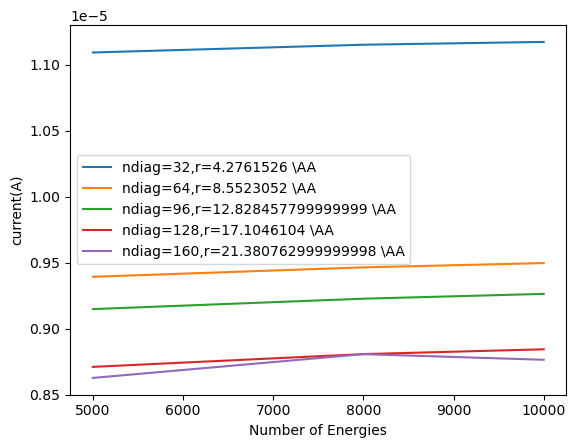

In [58]:
Lx=4.2761526
plt.plot(nen_list,ID_list[0,0,:],label='ndiag=32'+',r='+str(Lx*1)+r" \AA")
plt.plot(nen_list,ID_list64[0,0,:],label='ndiag=64'+',r='+str(Lx*2)+r" \AA")
plt.plot(nen_list,ID_list96[0,0,:],label='ndiag=96'+',r='+str(Lx*3)+r" \AA")
plt.plot(nen_list,ID_list128[0,0,:],label='ndiag=128'+',r='+str(Lx*4)+r" \AA")
plt.plot(nen_list,ID_list160[0,0,:],label='ndiag=160'+',r='+str(Lx*5)+r" \AA")
plt.xlabel('Number of Energies')
plt.ylabel('current(A)')
plt.legend()

Text(0, 0.5, 'E[eV]')

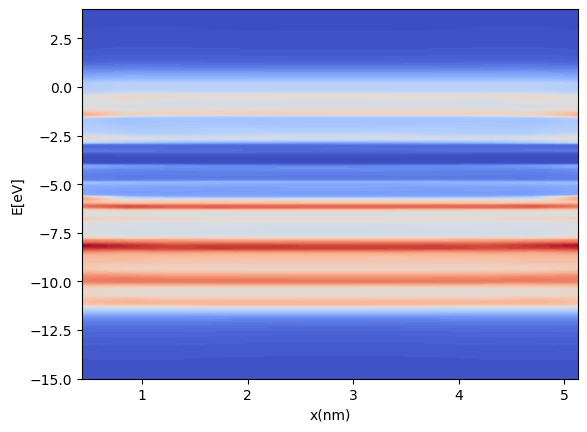

In [54]:
nx=12
emin=-15.0
emax= 4.0
ldos=np.loadtxt('last_ldos0001.dat')
nen=ldos.shape[0]//nx
en=np.linspace(emin,emax,nen)
x=np.linspace(1,nx,nx)*Lx
ldos=np.reshape(ldos[:,3],(nen,nx))
plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')
# plt.ylim(-5,0)

(-5.0, -2.0)

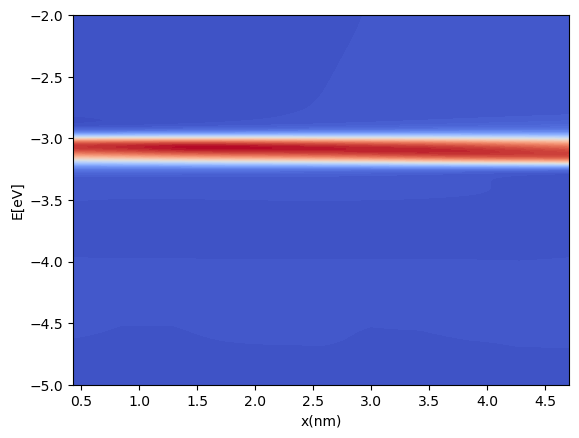

In [57]:
nx=11
jdens=np.loadtxt('last_Jdens0001.dat')
nen=jdens.shape[0]//nx
jdens=np.reshape(jdens[:,2],(jdens.shape[0]//nx,nx))
x=np.linspace(1,nx,nx)*Lx
en=np.linspace(emin,emax,nen)
plt.contourf(x/10,en,jdens,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')
plt.ylim(-5,-2)

In [33]:
ids=np.loadtxt('gw_Id_iteration.dat')
it=ids[:,0]
nn=[0]
for j in range(1,len(it)):
    if(it[j]<it[j-1]):
        nn.append(j)
        

Text(0.5, 1.0, 'right contact')

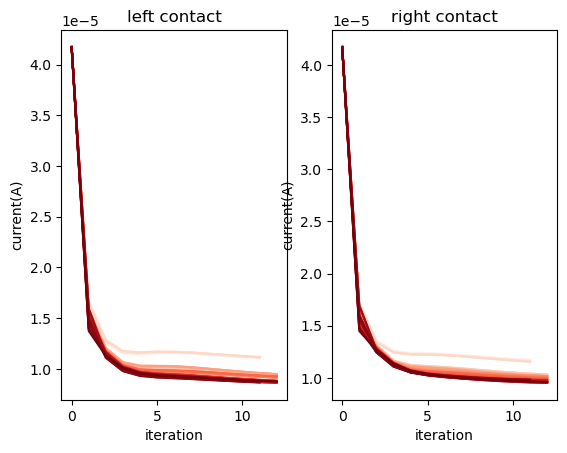

In [68]:
from matplotlib import cm
brewer_cmap = cm.get_cmap('Reds')
colors = brewer_cmap(np.linspace(0,1,len(nn)))

plt.subplot(1,2,1)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],1],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('current(A)')
plt.title('left contact')
plt.subplot(1,2,2)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],2],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('current(A)')
plt.title('right contact')